# LOF Algorithm for Anomaly Detection.
 - Local Outlier Factor for Anomaly Detection Algorithm.

In [1]:
import os 
os.environ["LOKY_MAX_CPU_COUNT"] = "8"

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
import numpy as np

### Load Data:

In [3]:
df = pd.read_csv("thyroid_dataset.csv")

In [4]:
df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


In [5]:
df.shape

(6916, 22)

In [6]:
X = df.drop("Outlier_label", axis=1)
y = df["Outlier_label"]

### Scaling Data:

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Applying Local Outlier Factor Algorithm:

In [8]:
from sklearn.neighbors import LocalOutlierFactor

In [9]:
clf = LocalOutlierFactor(contamination=0.036)
clf

,n_neighbors,20
,algorithm,'auto'
,leaf_size,30
,metric,'minkowski'
,p,2
,metric_params,None
,contamination,0.036
,novelty,False
,n_jobs,None


### Prediction

In [10]:
labels = clf.fit_predict(X_scaled)

### Visualizeing Data using PCA:

In [11]:
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)

Text(0.5, 1.0, 'Local Outlier Factor for Anomaly Detection.')

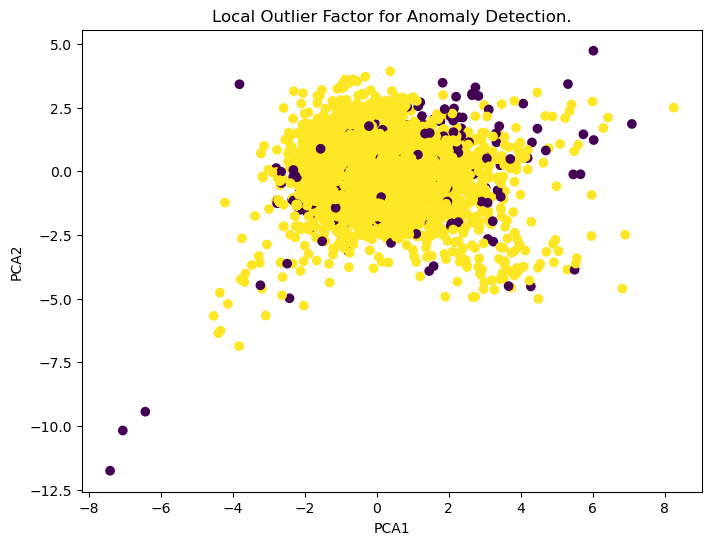

In [12]:
plt.figure(figsize  = (8, 6))
plt.scatter(X_pca[:, 0], X_pca[:,1], c = labels)
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("Local Outlier Factor for Anomaly Detection.")

### Number of Outliers & Normal Count:

In [13]:
n_outliers = np.sum(labels == -1)
n_normal = np.sum(labels == 1)

print(f"Number of outliers data are: {n_outliers}")
print(f"Number of non-outliers data are: {n_normal}")

Number of outliers data are: 249
Number of non-outliers data are: 6667
